In [9]:
import pandas as pd
import numpy as np
from helpers import get_feature_importance
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from joblib import dump, load

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report 
seed = 42

In [10]:
df = pd.read_csv('bank.csv')

In [11]:
# ====== 1. Разделение на X и y ======
X = df.drop('deposit', axis=1)
y = df['deposit'].map({'yes': 1, 'no': 0})  # бинаризация таргета

# ====== 2. Определение типов признаков ======
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns

# ====== 3. Препроцессинг ======
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore')) # handle_unknown='ignore' для исключения ошибки, если в тесте будет новая категория
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# ====== 4. Разбиение с stratify ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=seed,
    stratify=y  # разбиенте со стратификацией
)

# ====== 5. Модели ======
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(random_state=seed),
    'XGBoost': XGBClassifier(
        eval_metric='logloss',
        random_state=seed
    )
}

# ====== 6. Кросс-валидация ======
scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed) # разбиенте со стратификацией

cross_val_res = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    cross_val={}
    for metric in scoring:
        mean_score = cv_results[f'test_{metric}'].mean()
        std_score = cv_results[f'test_{metric}'].std()
        cross_val[metric] = str(round(mean_score, 4)) + ' ± ' + str(round(std_score, 4))
    cross_val_res[name] = cross_val

result_cross_val = pd.DataFrame(cross_val_res).T

#====== 7. Финальное обучение и тест ======
list_of_models=[]
results={}
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    list_of_models.append(pipeline)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, y_pred_proba)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = [roc, accuracy, precision, recall, f1]

result_test = pd.DataFrame(results, index=['roc_auc', 'accuracy', 'precision', 'recall', 'f1']).T

In [13]:
print('')
print('Результаты на кросс-валидации')
print('')
display(result_cross_val)


Результаты на кросс-валидации



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.9016 ± 0.0043,0.8238 ± 0.0074,0.8274 ± 0.0055,0.7939 ± 0.0188,0.8102 ± 0.0097
RandomForest,0.9184 ± 0.0045,0.85 ± 0.0073,0.8203 ± 0.0052,0.8752 ± 0.0126,0.8468 ± 0.0081
XGBoost,0.9203 ± 0.0052,0.8513 ± 0.0053,0.8263 ± 0.0047,0.8688 ± 0.0133,0.847 ± 0.0063


In [14]:
print('')
print('Результаты на тестовой выборке')
print('')
display(result_test)


Результаты на тестовой выборке



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.907297,0.825347,0.827451,0.797732,0.812320
RandomForest,0.919328,0.861621,0.831709,0.887524,0.858711
XGBoost,0.925727,0.864308,0.841012,0.879962,0.860046


In [8]:
# сохраним результаты, они нам пригодятся в дальнейшем
dump(result_cross_val, 'result_cross_val_baseline.joblib')
dump(result_test, 'result_test_baseline.joblib')

['result_test_baseline.joblib']

## Коэффициенты модели логистической регресии и важности признаков по RandomForest и XGBoost

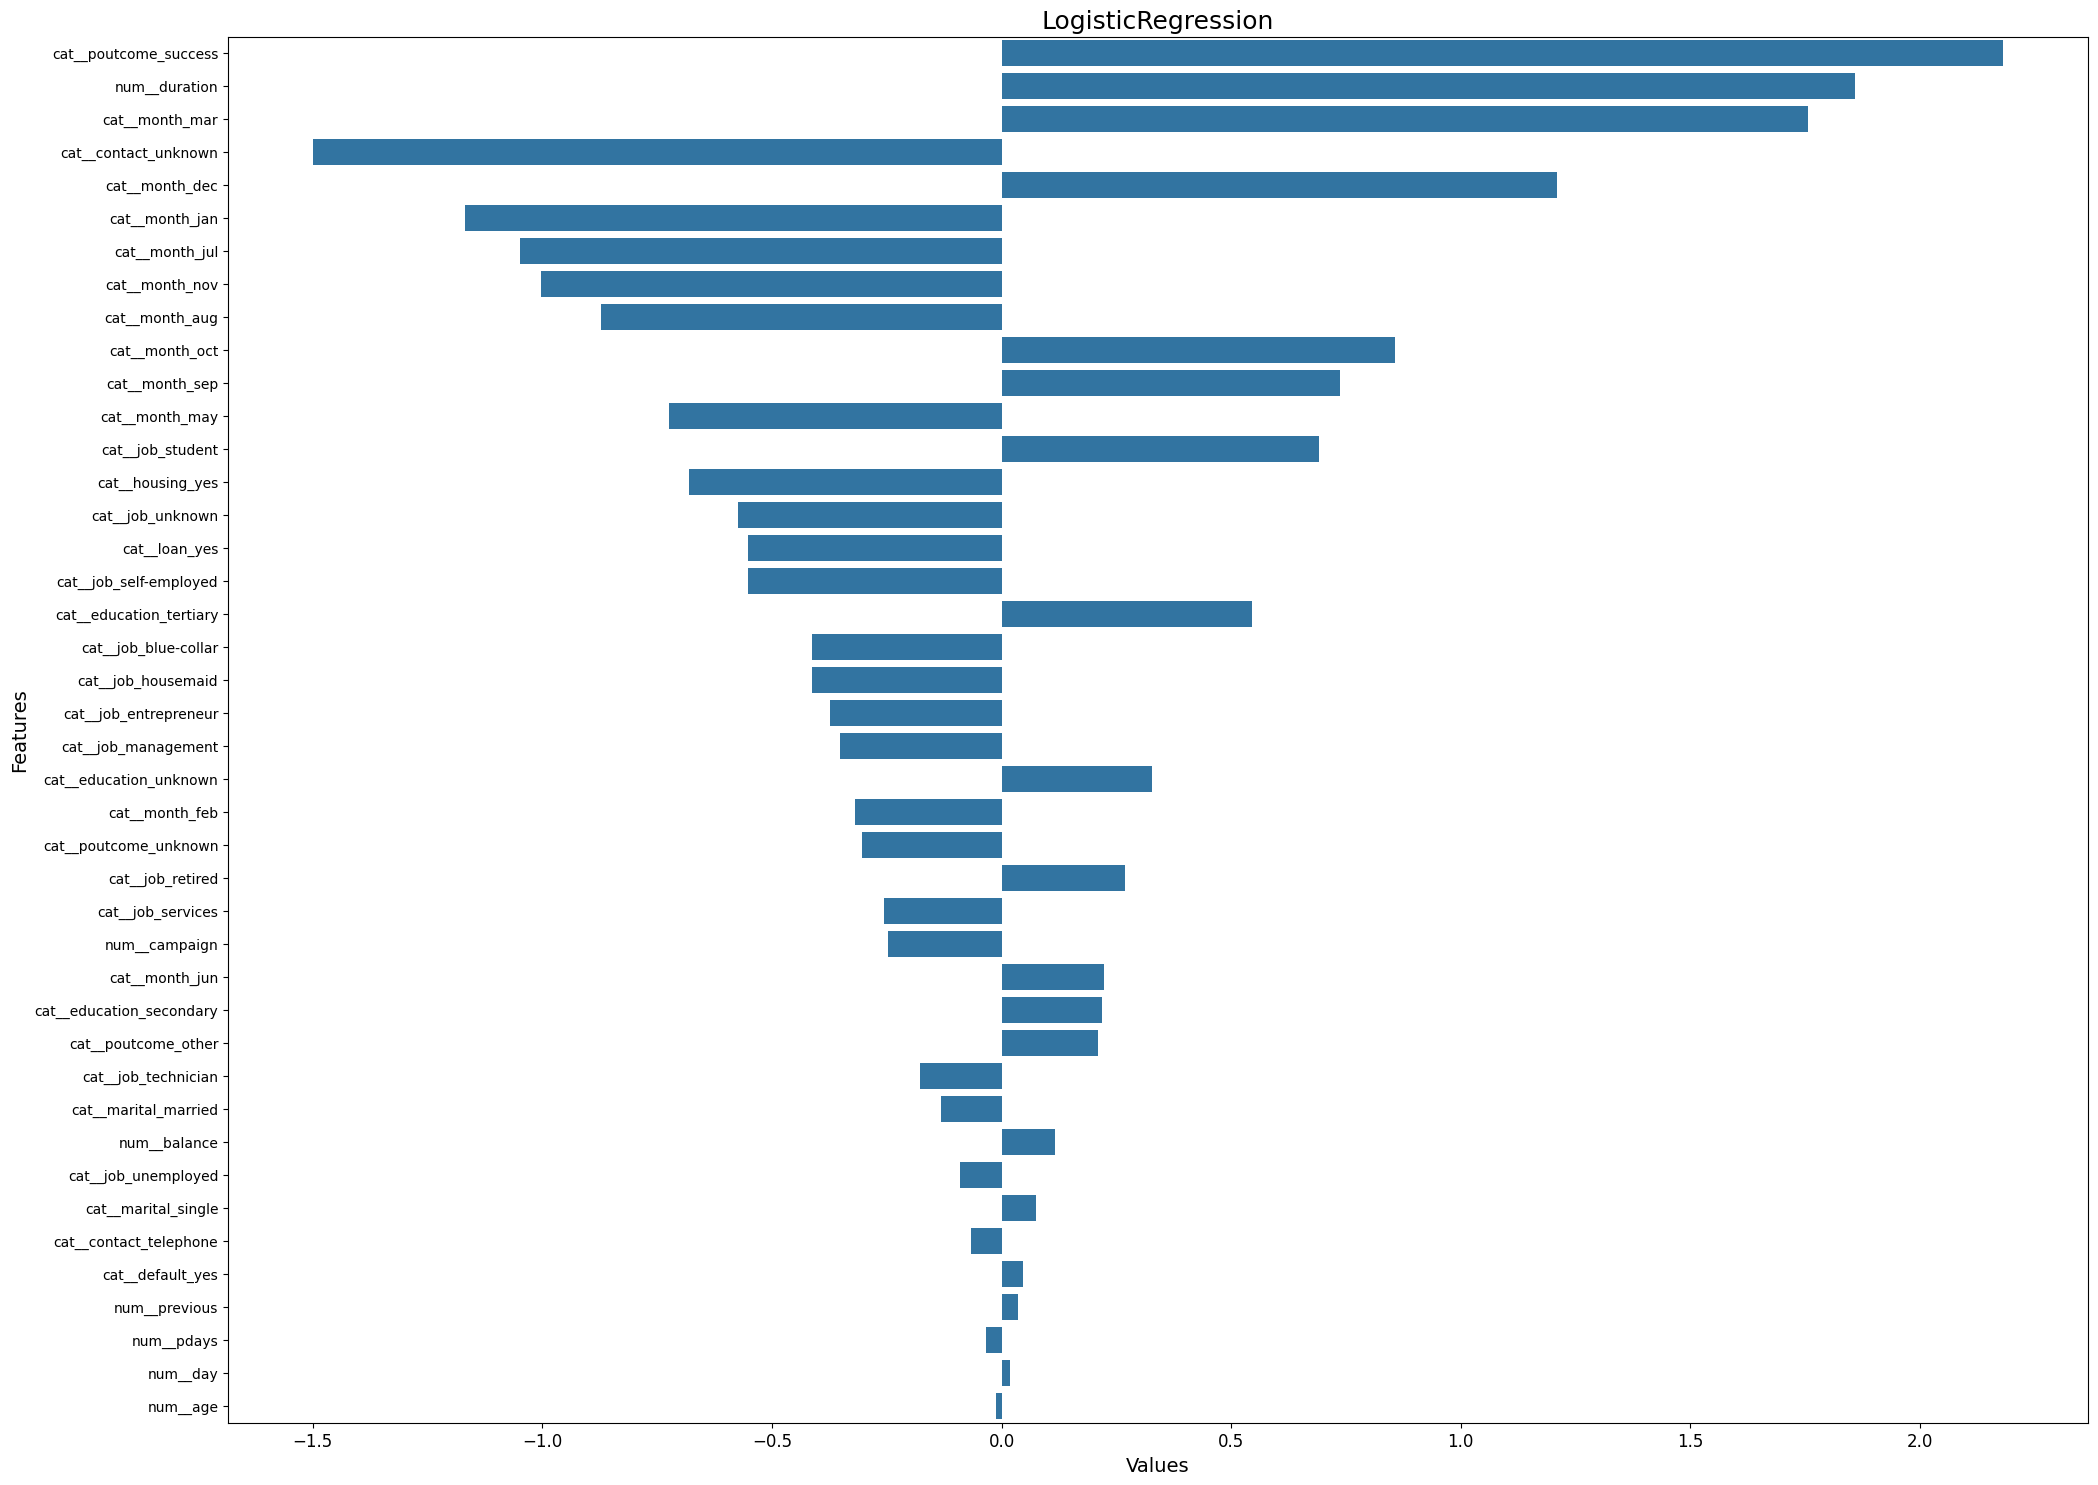

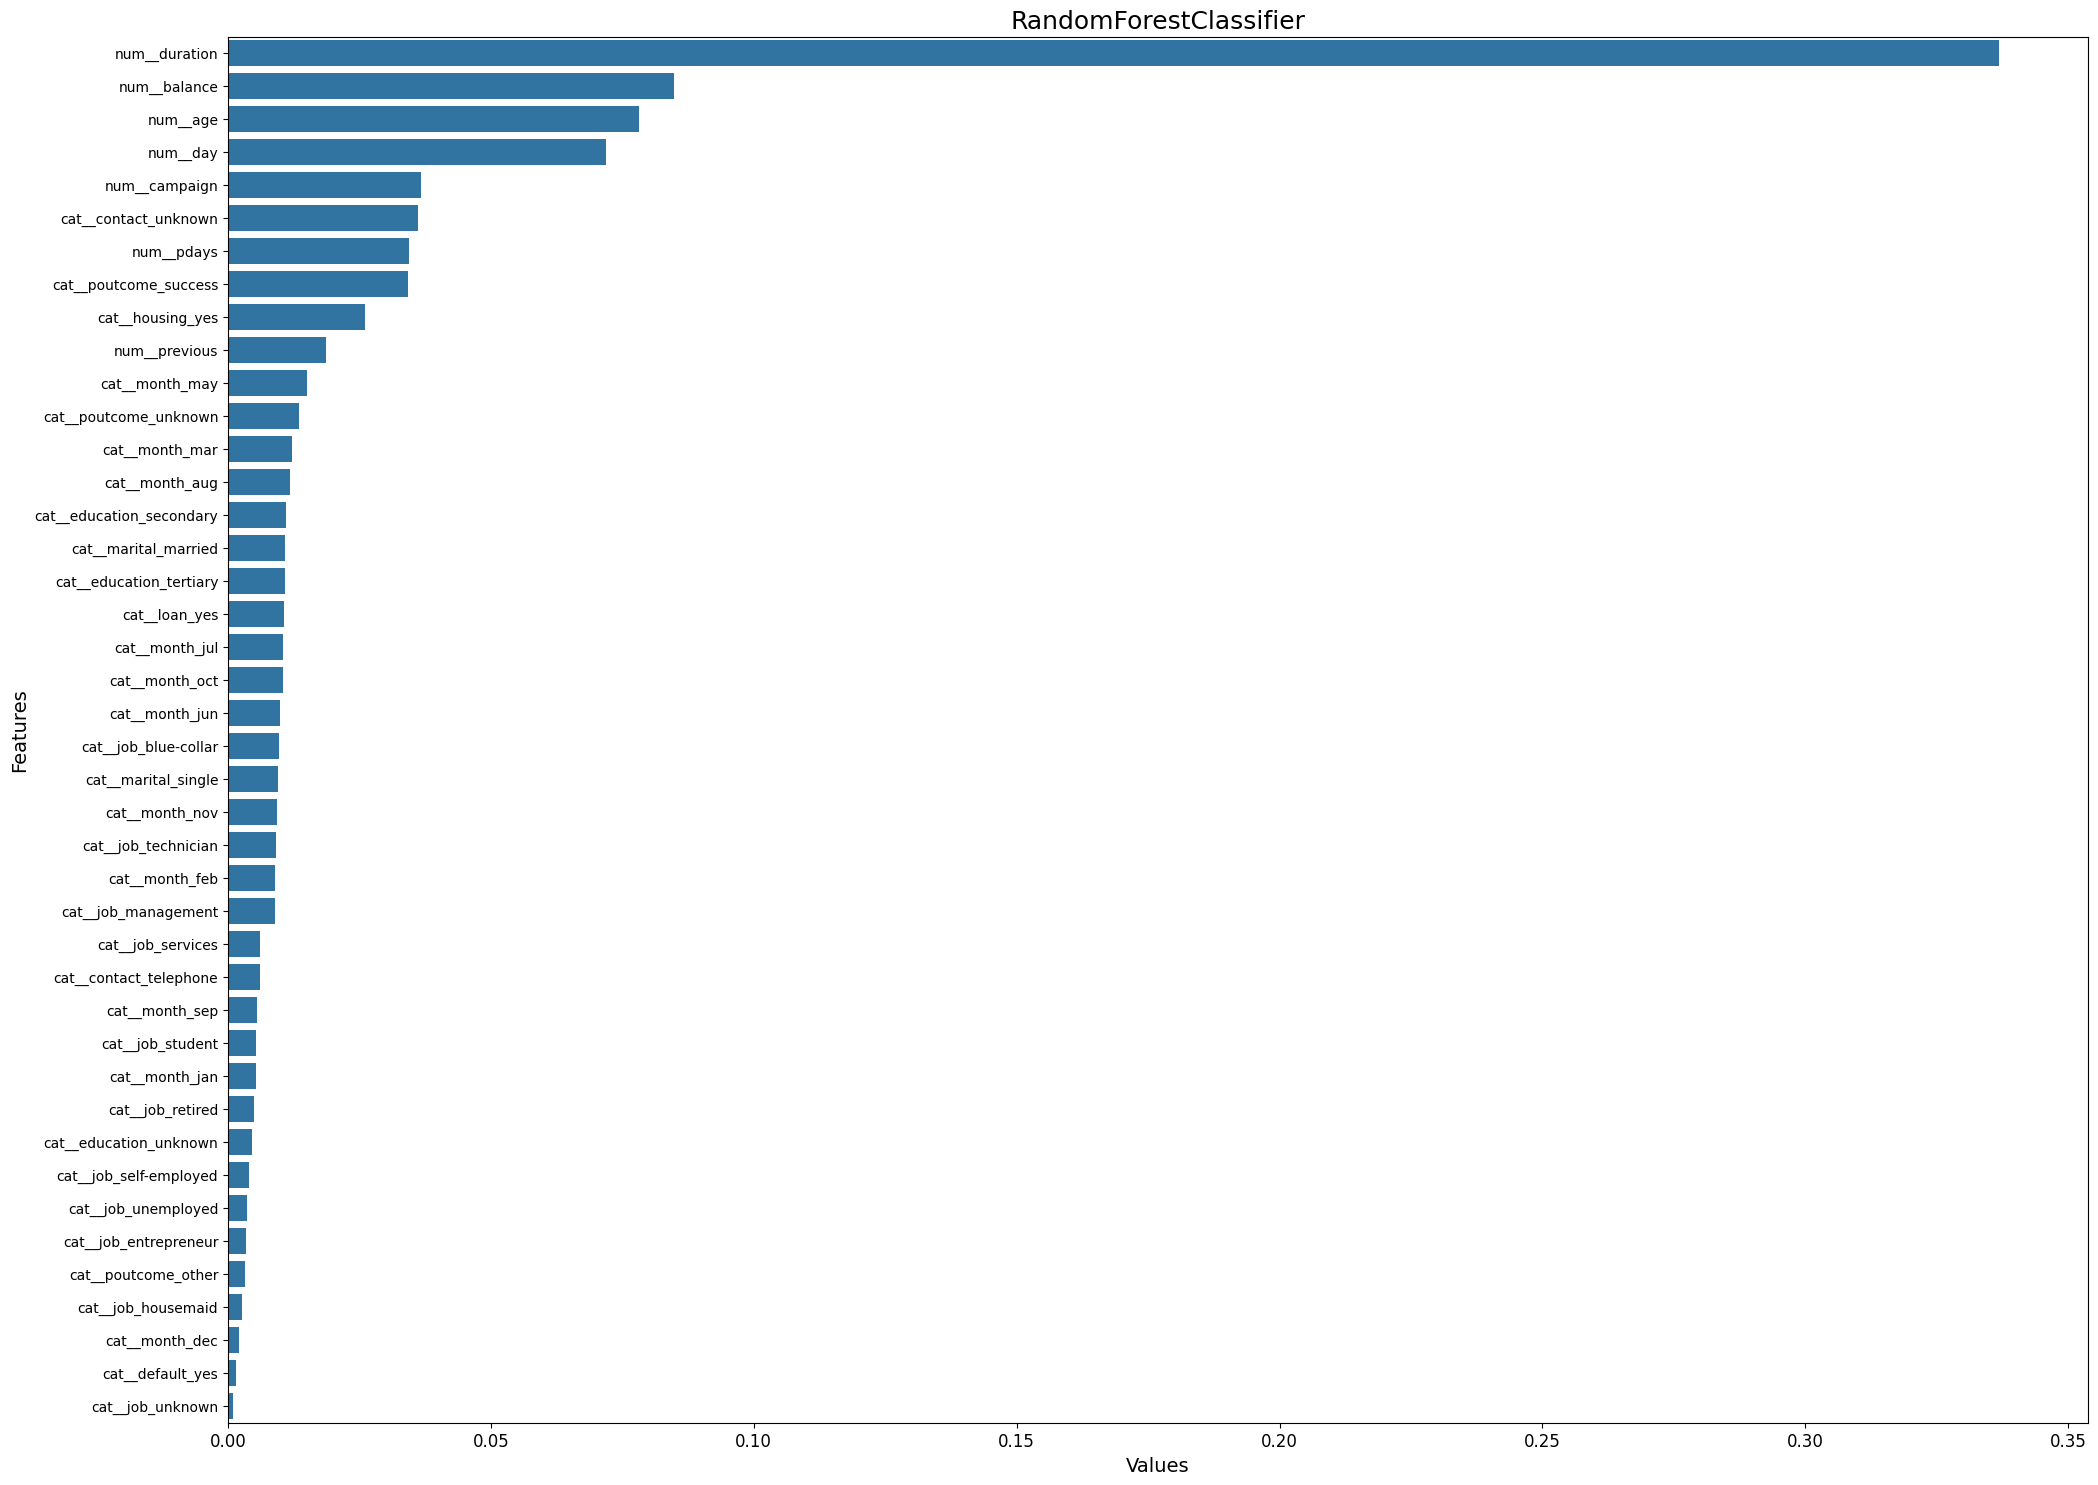

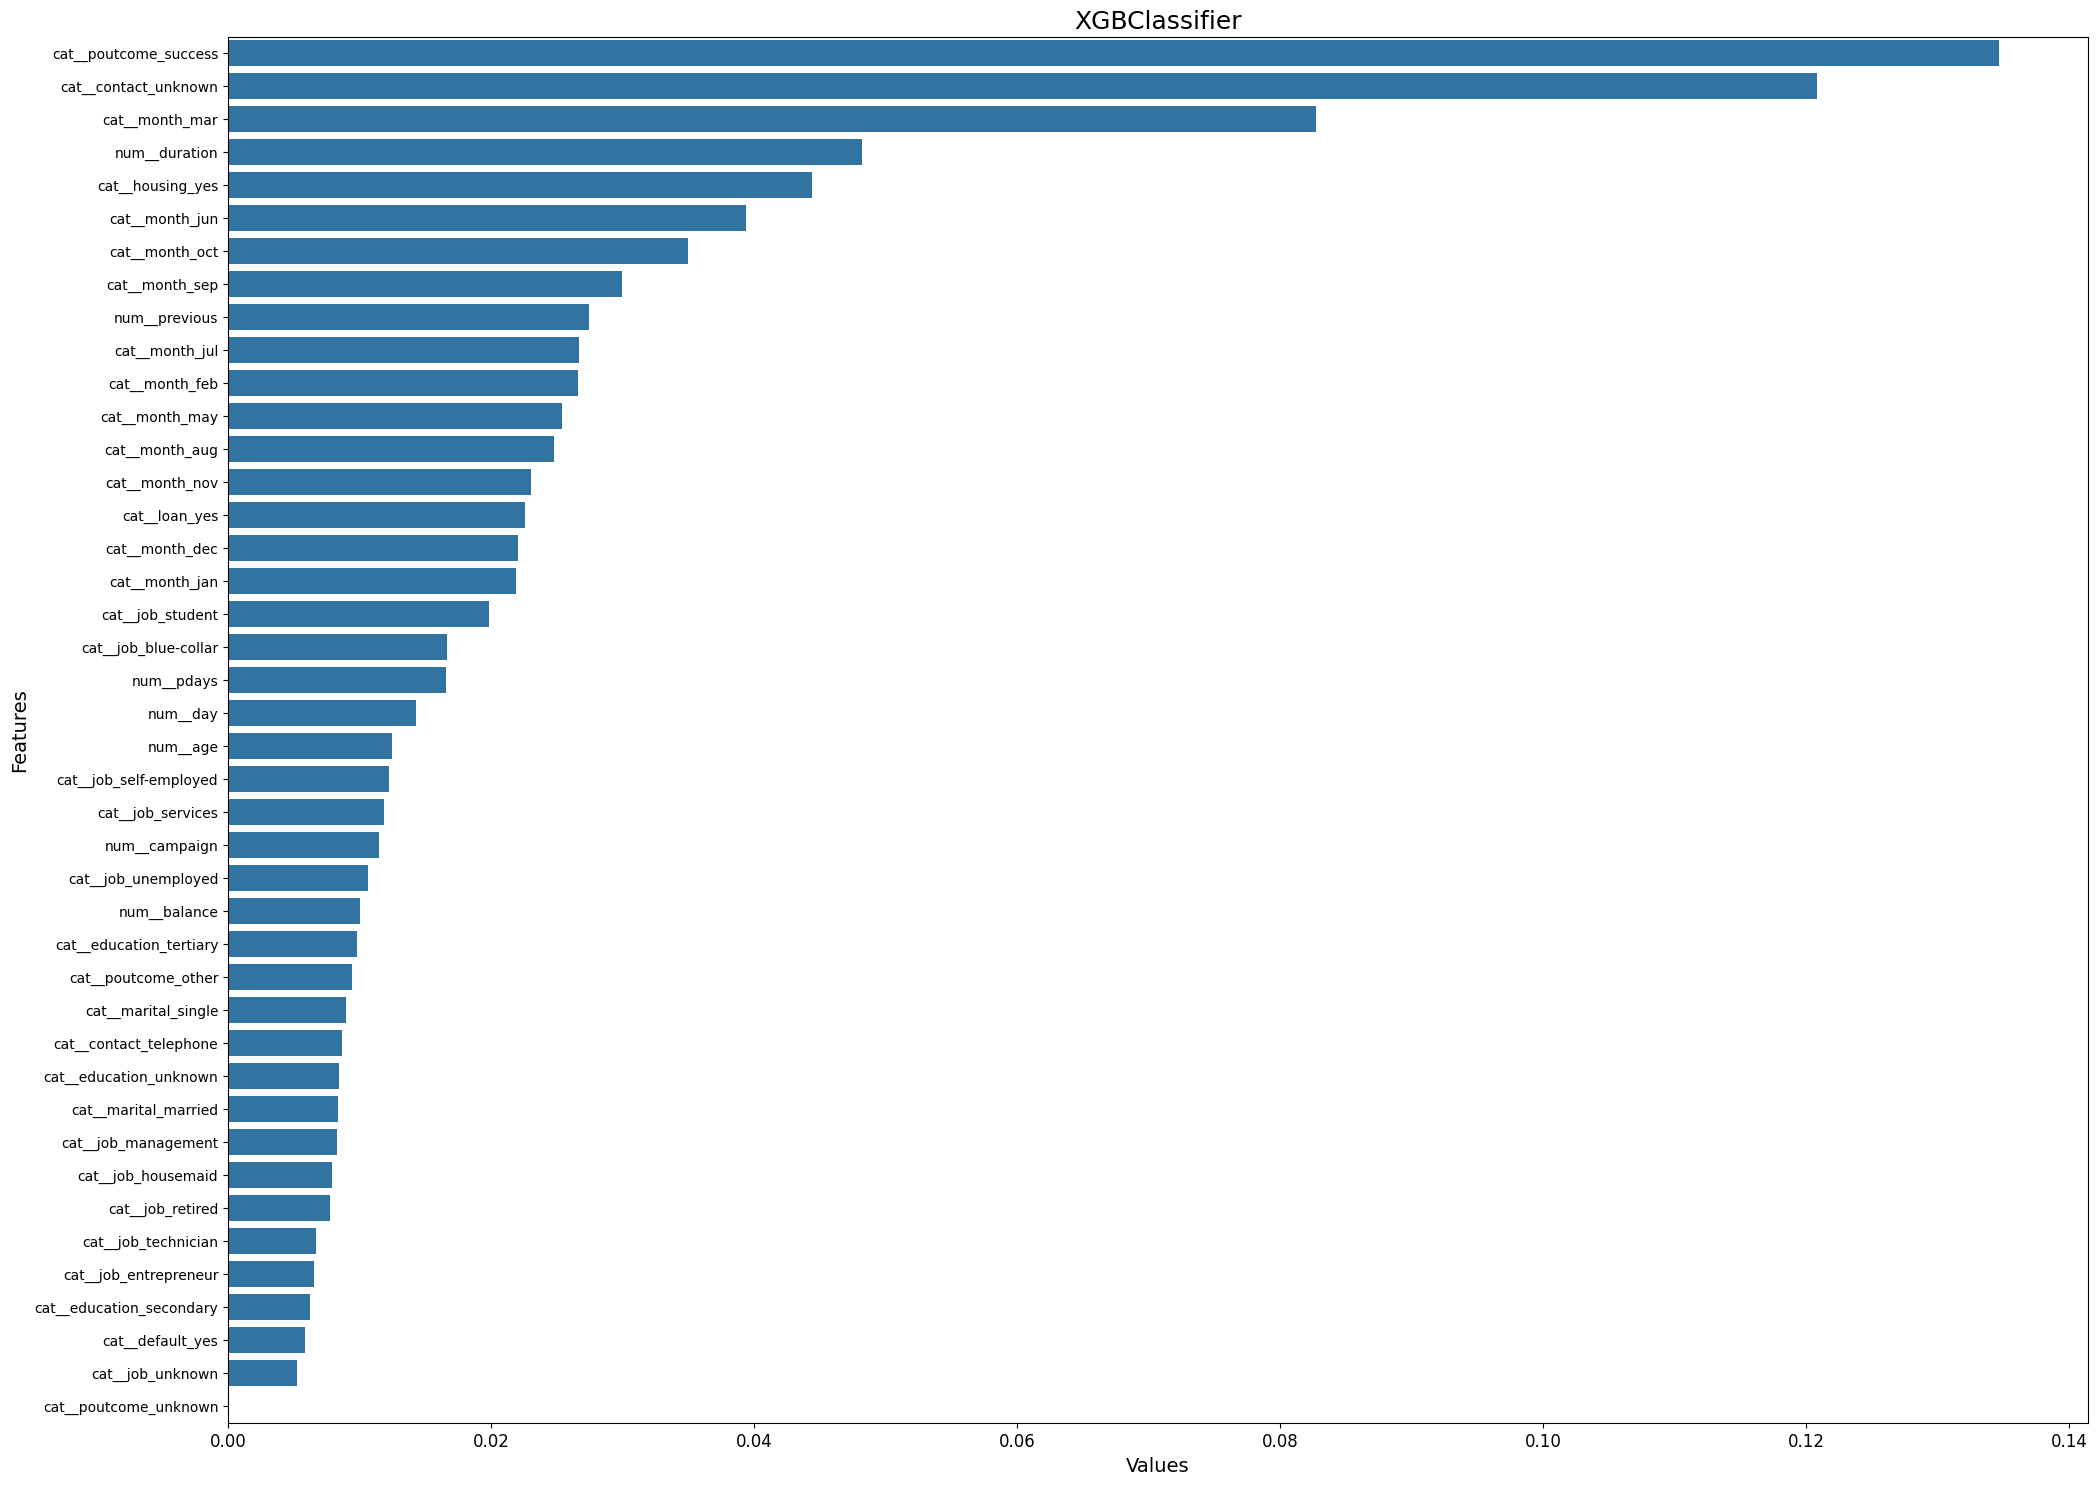

In [12]:
get_feature_importance(list_of_models)